# Assignment 03 - Python

Authors : GILLES Chloé, AHMAD Albatoul,BALBINE Valentin

## Introduction
 This is the notebook to complete the assignment 03 of Python,R and Git.

In [2]:
#Import libraries to compute numbers and plot graphs
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'signal')

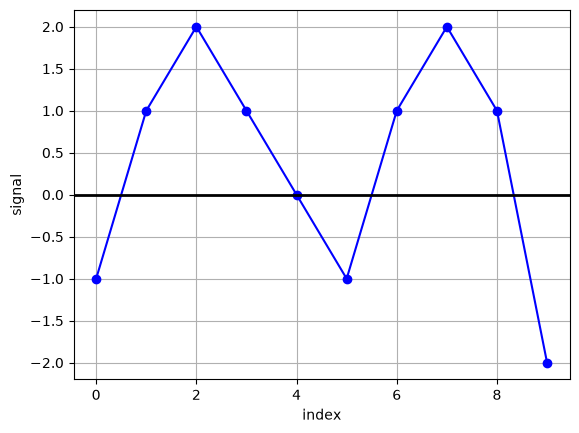

In [3]:
# Plot a simple sampled signal 

s = [-1, 1, 2, 1, 0, -1, 1, 2, 1, -2]

signal = np.array(s)#make a numpy array from the list s
plt.plot(signal, marker='o', linestyle='-', color='b')
grid = True
plt.grid(grid)
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('index')
plt.ylabel('signal')


## find the zero crossings

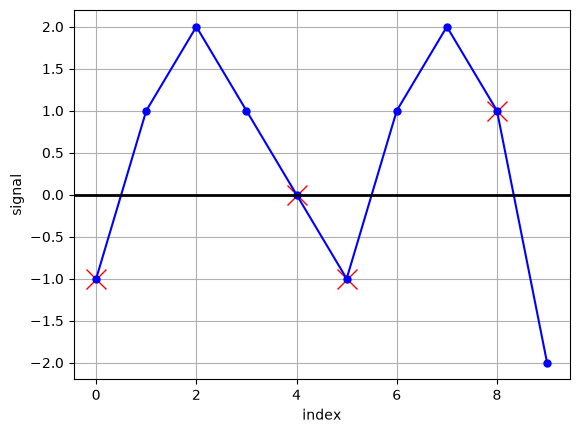

In [4]:
# find the zero crossings in the signal
zero_crossings = np.where(np.sign(signal[:-1]) * np.sign(signal[1:]) < 0)[0]
#zero_crossings = np.where(np.diff(np.sign(signal)) != 0)[0]
zero_values = np.where(signal == 0)[0]
zero_crossings = np.concatenate((zero_crossings, zero_values))

# Mark the zero crossings on the plot
# plot the signal xith the zero crossings marked with red circles

for i in zero_crossings:
    plt.plot(i, signal[i], 'rx', markersize=15)

plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
grid = True
plt.grid(grid)
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('index')
plt.ylabel('signal')

plt.show()



## Find the positive and negative zero crossings

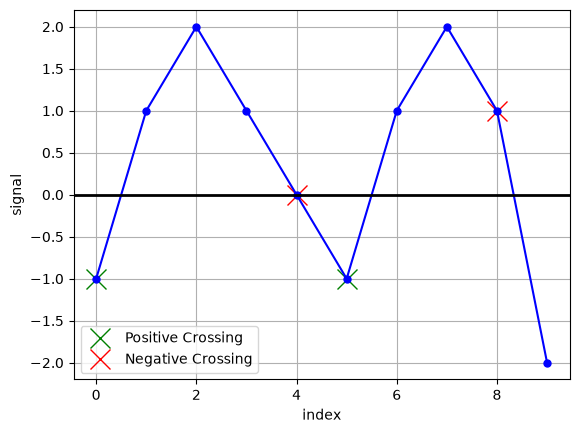

In [5]:
# find the positive and negative zero crossings in the signal
positive_crossings = np.where((signal[:-1] < 0) & (signal[1:] > 0))[0]
negative_crossings = np.where((signal[:-1] > 0) & (signal[1:] < 0))[0]
zero_values = np.where(signal == 0)[0]

# also mark the actual zero values in the signal
# How can we tell if this zero value is positive or negative? We can check the sign of the previous and next values in the signal. If the previous value is negative and the next value is positive, then this zero value is a positive crossing. If the previous value is positive and the next value is negative, then this zero value is a negative crossing. If both previous and next values are zero, then we can consider this zero value as a neutral crossing.
# we code this
if len(zero_values) > 0:
    for i in zero_values:
        if i > 0 and i < len(signal) - 1:
            if signal[i - 1] < 0 and signal[i + 1] > 0:
                positive_crossings = np.append(positive_crossings, i)
            elif signal[i - 1] > 0 and signal[i + 1] < 0:
                negative_crossings = np.append(negative_crossings, i)
                break

# Mark the positive and negative zero crossings on the plot
for i in positive_crossings:
    plt.plot(i, signal[i], 'gx', markersize=15, label='Positive Crossing' if i == positive_crossings[0] else "")

for i in negative_crossings:
    plt.plot(i, signal[i], 'rx', markersize=15, label='Negative Crossing' if i == negative_crossings[0] else "")

plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
grid = True
plt.grid(grid)
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('index')
plt.ylabel('signal')
legend = plt.legend(loc='lower left') 


## Find the local minima and maxima points.

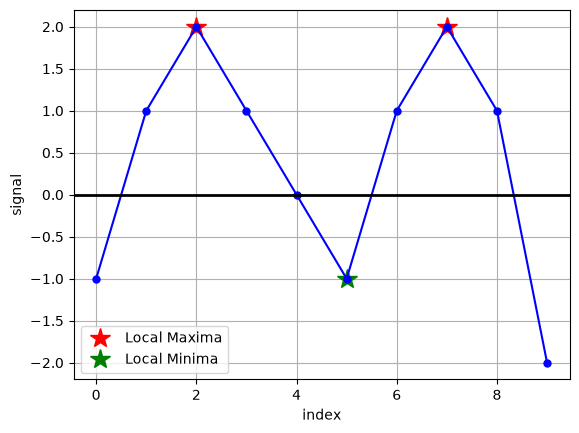

In [6]:
# find the local maxima and minima in the signal
from scipy.signal import argrelextrema

# Find the indices of the local maxima
local_maxima = argrelextrema(signal, np.greater)

# Find the indices of the local minima
local_minima = argrelextrema(signal, np.less)

# Mark the local maxima and minima on the plot
for i in local_maxima[0]:
    plt.plot(i, signal[i], 'r*', markersize=15, label='Local Maxima' if i == local_maxima[0][0] else "")

for i in local_minima[0]:
    plt.plot(i, signal[i], 'g*', markersize=15, label='Local Minima' if i == local_minima[0][0] else "")

plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
grid = True
plt.grid(grid)
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
plt.xlabel('index')
plt.ylabel('signal')
legend = plt.legend(loc='lower left') 

## 2.3 Create new functions to find the local maxima and minima

### function for zero crossing

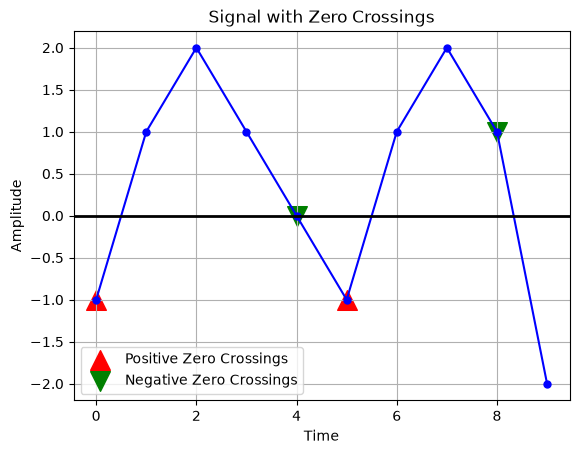

In [9]:
# ccreate function to find the positive and negative zero crossings in a signal and plot them
def plot_zero_crossings(signal):
    # Find the indices of the zero crossings
    positive_crossings = np.where((signal[:-1] < 0) & (signal[1:] > 0))[0]
    negative_crossings = np.where((signal[:-1] > 0) & (signal[1:] < 0))[0]
    zero_values = np.where(signal == 0)[0]

    # also mark the actual zero values in the signal
    # How can we tell if this zero value is positive or negative? We can check the sign of the previous and next values in the signal. If the previous value is negative and the next value is positive, then this zero value is a positive crossing. If the previous value is positive and the next value is negative, then this zero value is a negative crossing. If both previous and next values are zero, then we can consider this zero value as a neutral crossing.
    # we code this
    if len(zero_values) > 0:
        for i in zero_values:
            if i > 0 and i < len(signal) - 1:
                if signal[i - 1] < 0 and signal[i + 1] > 0:
                    positive_crossings = np.append(positive_crossings, i)
                elif signal[i - 1] > 0 and signal[i + 1] < 0:
                    negative_crossings = np.append(negative_crossings, i)
                    break
                else:
                    # if both previous and next values are zero, we can consider this zero value as a neutral crossing
                    pass

    for k, i in enumerate(positive_crossings):              
        plt.scatter(i, signal[i], marker='^', label='Positive Zero Crossings' if k == 0 else "", s=200, color='red')

    for k, i in enumerate(negative_crossings): 
        plt.scatter(i, signal[i], marker='v', label='Negative Zero Crossings' if k == 0 else "", s=200, color='green')

    
plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
signal_with_zero_crossings = plot_zero_crossings(signal)
plt.title('Signal with Zero Crossings')
plt.xlabel('Time')
plt.ylabel('Amplitude')
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
grid = True
plt.grid(grid)
plt.legend(loc='lower left')


### Function for local minima and maxima

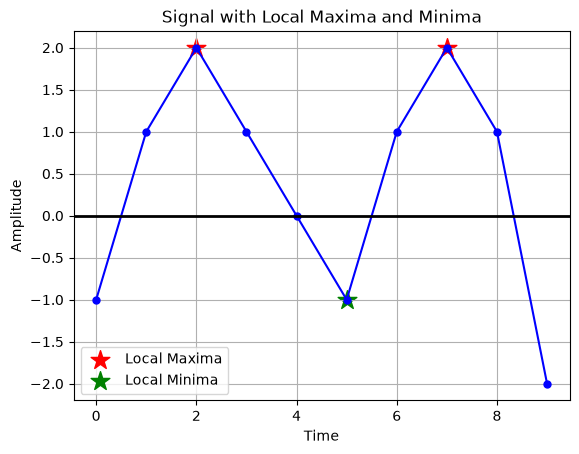

In [10]:
# create function to find the local maxima and minima in a signal and plot them
def plot_local_extrema(signal):
    # Find the indices of the local maxima
    local_maxima = argrelextrema(signal, np.greater)

    # Find the indices of the local minima
    local_minima = argrelextrema(signal, np.less)

    # Mark the local maxima and minima on the plot
    for k, i in enumerate(local_maxima[0]):
        plt.scatter(i, signal[i], marker='*', label='Local Maxima' if k == 0 else "", s=200, color='red')

    for k, i in enumerate(local_minima[0]):
        plt.scatter(i, signal[i], marker='*', label='Local Minima' if k == 0 else "", s=200, color='green')


plt.plot(signal, marker='o', linestyle='-', color='b', markersize=5)
signal_with_local_extrema = plot_local_extrema(signal)
plt.title('Signal with Local Maxima and Minima')
plt.xlabel('Time')
plt.ylabel('Amplitude')
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
grid = True
plt.grid(grid)
plt.legend(loc='lower left')

# 3 Analyze a known signal

## 3.1  Create the signal and plot it

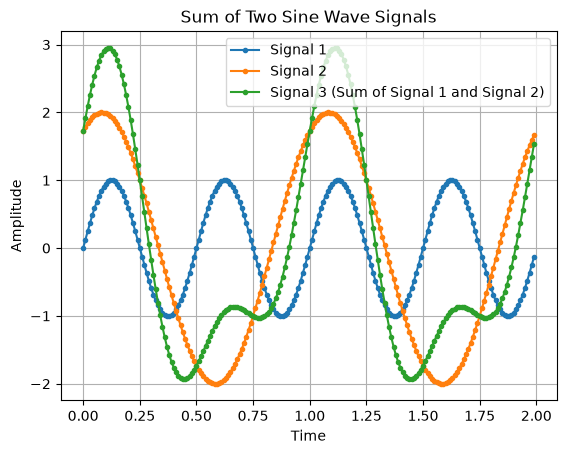

In [7]:
# plot a signal as a sum of two sine wave signals with different frequencies and amplitudes
# plot all three together in one plot

fs = 100 # sampling frequency (60 Hz)
duration = 2 # seconds
t = np.arange(0, duration, 1/fs)

s1 = np.sin(2 * np.pi * 2 * t) 
s2 = 2 * np.sin(2 * np.pi * 1 * t + np.pi / 3)
s3 = s1 + s2

plt.plot(t, s1, '.-', label='Signal 1')
plt.plot(t, s2, '.-', label='Signal 2')
plt.plot(t, s3, '.-', label='Signal 3 (Sum of Signal 1 and Signal 2)')
plt.title('Sum of Two Sine Wave Signals')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

## 3.2 plot the remarkable points

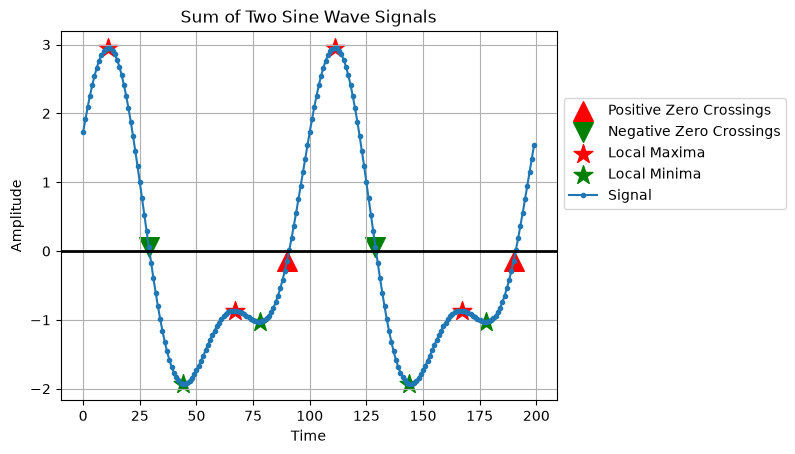

In [11]:
signal_with_zero_crossings = plot_zero_crossings(s3)
signal_with_local_extrema = plot_local_extrema(s3)

plt.plot(s3, '.-', label='Signal')
plt.title('Sum of Two Sine Wave Signals')
plt.xlabel('Time')
plt.ylabel('Amplitude')
# make the 0 axis bold
plt.axhline(y=0, color='black', linewidth=2)
# put the legend out of the picture
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.grid(True)

## 3.3 Use the remarkable points to find the frequency of the signal

we defined a new find_zero_crossing function to find the values without plotting them

In [12]:
# ccreate function to find the positive and negative zero crossings in a signal and plot them
def find_zero_crossings(signal):
    # Find the indices of the zero crossings
    positive_crossings = np.where((signal[:-1] < 0) & (signal[1:] > 0))[0]
    negative_crossings = np.where((signal[:-1] > 0) & (signal[1:] < 0))[0]
    zero_values = np.where(signal == 0)[0]

    # also mark the actual zero values in the signal
    # How can we tell if this zero value is positive or negative? We can check the sign of the previous and next values in the signal. If the previous value is negative and the next value is positive, then this zero value is a positive crossing. If the previous value is positive and the next value is negative, then this zero value is a negative crossing. If both previous and next values are zero, then we can consider this zero value as a neutral crossing.
    # we code this
    if len(zero_values) > 0:
        for i in zero_values:
            if i > 0 and i < len(signal) - 1:
                if signal[i - 1] < 0 and signal[i + 1] > 0:
                    positive_crossings = np.append(positive_crossings, i)
                elif signal[i - 1] > 0 and signal[i + 1] < 0:
                    negative_crossings = np.append(negative_crossings, i)
                    break
                else:
                    # if both previous and next values are zero, we can consider this zero value as a neutral crossing
                    pass
    return positive_crossings, negative_crossings

We use the remarkable points to find the frequency of the signal.

*Idea:* two zero crossings with the same slope (two positive ones, or two negative ones) are separated by exactly *one period*.

*Method:*
1. find_zero_crossings returns the indices of the positive and the negative crossings.
2. np.diff gives the number of *samples* between two consecutive crossings of the same type.
3. Multiply by the sampling step dt to convert samples into seconds, so we get the period.
4. Average the "positive" and "negative" estimates, then frequency = 1 / period.

In [13]:
def compute_frequency_from_zero_crossings(time, signal):
    """Estimate the period and frequency of a signal from its zero crossings.

    Inputs : time (1D array, seconds, uniform sampling), signal (1D array, same length)
    Output : dictionary with the spacing between crossings (samples),
             the periods (s) and the frequency (Hz)
    """
    dt = time[1] - time[0]                       # sampling step (s)

    # 1. indices of the crossings (sorted, because zero values were appended at the end)
    positive_crossings, negative_crossings = find_zero_crossings(signal)
    positive_crossings = np.sort(positive_crossings)
    negative_crossings = np.sort(negative_crossings)

    # 2. samples between two consecutive crossings of the same slope
    delta_pos = np.diff(positive_crossings)
    delta_neg = np.diff(negative_crossings)

    # 3. convert to seconds: period = mean spacing * dt
    period_pos = np.mean(delta_pos) * dt
    period_neg = np.mean(delta_neg) * dt

    # 4. final period = average of both estimates, frequency = 1 / period
    period = (period_pos + period_neg) / 2

    return {
        "delta_zero_crossing_pos (samples)": delta_pos,
        "delta_zero_crossing_neg (samples)": delta_neg,
        "signal_period_pos (s)": period_pos,
        "signal_period_neg (s)": period_neg,
        "signal_period (s)": period,
        "signal_frequency (Hz)": 1 / period,
    }


def print_frequency_info(info):
    """Print the dictionary nicely (labels right-aligned)."""
    for key, value in info.items():
        print(f"{key:>35} : {value}")

### test on the known signal

The signal has a 1 s period (the 1 Hz sine dominates), sampled at 100 Hz, so we expect
*100 samples* between two crossings of the same slope, a period of *1.0 s* and a frequency of *1.0 Hz*.

In [14]:
info = compute_frequency_from_zero_crossings(t, s3)
print_frequency_info(info)

  delta_zero_crossing_pos (samples) : [100]
  delta_zero_crossing_neg (samples) : [100]
              signal_period_pos (s) : 1.0
              signal_period_neg (s) : 1.0
                  signal_period (s) : 1.0
              signal_frequency (Hz) : 1.0
